In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
print(df.head())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [ ]:
print(df.dtypes)

print(df.isnull().sum())

print(df.describe())

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


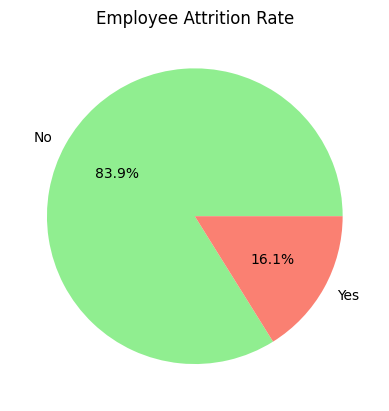

In [ ]:
attrition_count = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_count)
print(attrition_pct)


import matplotlib.pyplot as plt
attrition_count.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Employee Attrition Rate')
plt.ylabel('')
plt.show()

Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


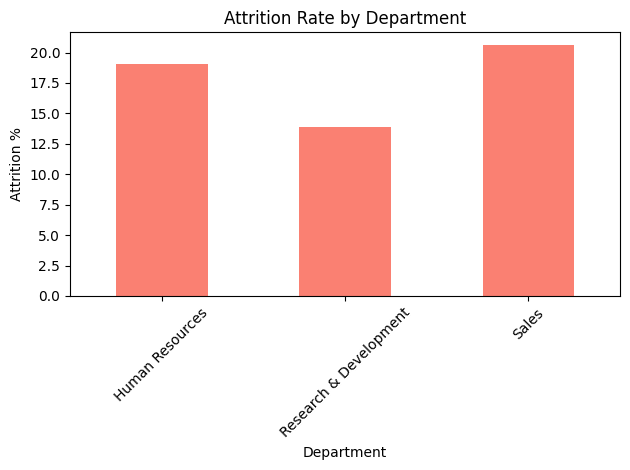

In [ ]:
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
print(dept_attrition)

dept_attrition['Yes'].plot(kind='bar', color='salmon')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846


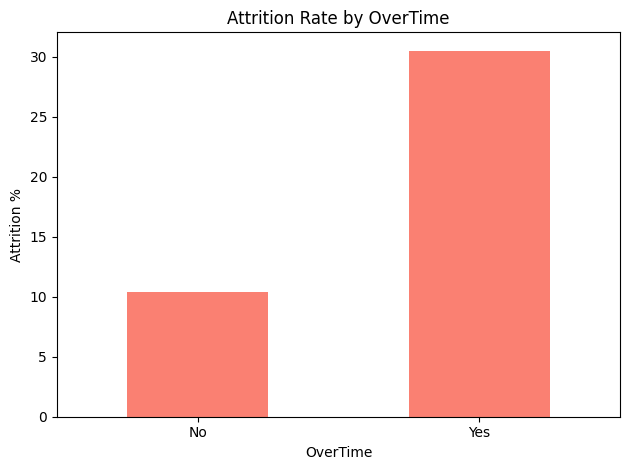

In [ ]:
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100
print(overtime_attrition)

overtime_attrition['Yes'].plot(kind='bar', color='salmon')
plt.title('Attrition Rate by OverTime')
plt.xlabel('OverTime')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


/tmp/ipykernel_1382/160849346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')


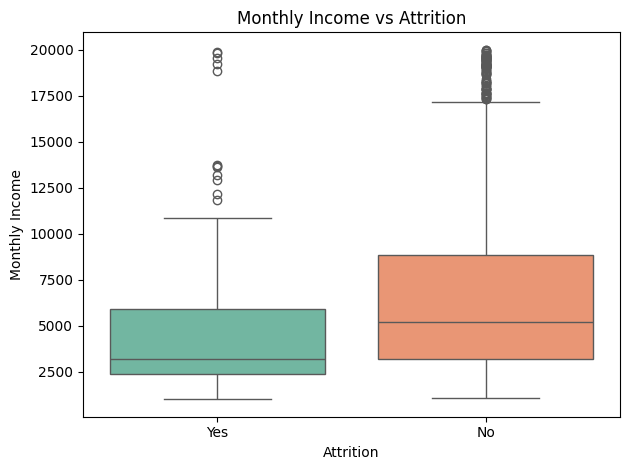

In [ ]:
avg_salary = df.groupby('Attrition')['MonthlyIncome'].mean()
print(avg_salary)

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64


/tmp/ipykernel_1382/1513857285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', palette='Set3')


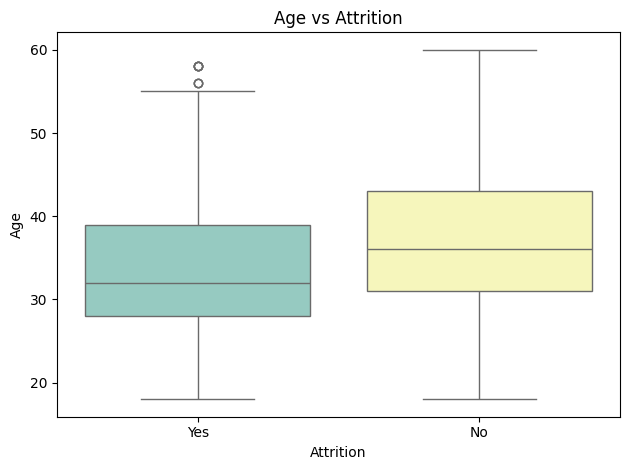

In [ ]:
avg_age = df.groupby('Attrition')['Age'].mean()
print(avg_age)

sns.boxplot(data=df, x='Attrition', y='Age', palette='Set3')
plt.title('Age vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

JobSatisfaction    1    2    3    4
Attrition                          
No               223  234  369  407
Yes               66   46   73   52
Attrition               No        Yes
JobSatisfaction                      
1                77.162630  22.837370
2                83.571429  16.428571
3                83.484163  16.515837
4                88.671024  11.328976


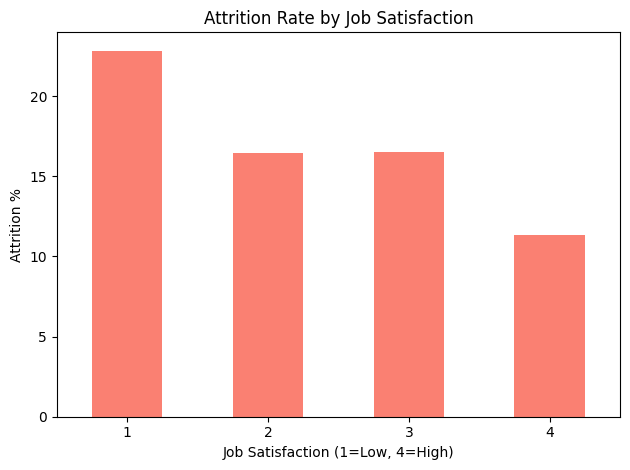

In [ ]:
job_sat = df.groupby(['Attrition','JobSatisfaction']).size().unstack()
print(job_sat)

job_sat_pct = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack() * 100
print(job_sat_pct)

job_sat_pct['Yes'].plot(kind='bar', color='salmon')
plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Attrition               No        Yes
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059


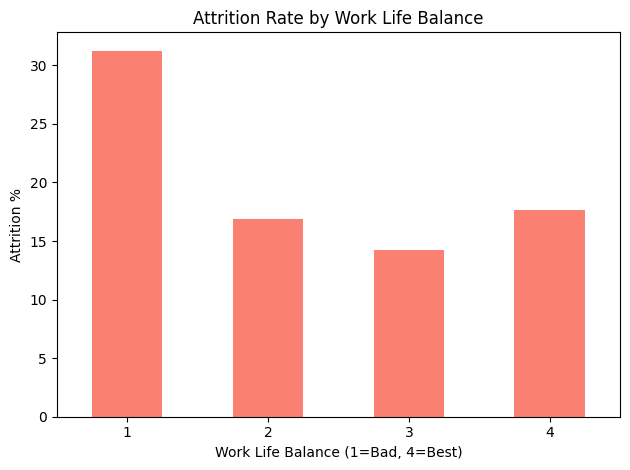

In [ ]:
wlb = df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack() * 100
print(wlb)

wlb['Yes'].plot(kind='bar', color='salmon')
plt.title('Attrition Rate by Work Life Balance')
plt.xlabel('Work Life Balance (1=Bad, 4=Best)')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
travel = df.groupby('BusinessTravel')['Attrition'].value_counts(normalize=True).unstack() * 100
print(travel)

Attrition                 No        Yes
BusinessTravel                         
Non-Travel         92.000000   8.000000
Travel_Frequently  75.090253  24.909747
Travel_Rarely      85.043145  14.956855


In [ ]:
avg_years = df.groupby('Attrition')['YearsAtCompany'].mean()
print(avg_years)

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64


In [ ]:
jobrole = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
print(jobrole['Yes'].sort_values(ascending=False))

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Yes, dtype: float64


In [ ]:
# Only filter sales department
sales_df = df[df['Department'] == 'Sales']

# In sales Overtime vs Attrition
sales_overtime = sales_df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100
print("Overtime vs Attrition (Sales only):")
print(sales_overtime)

# In sales Salary vs Attrition
sales_salary = sales_df.groupby('Attrition')['MonthlyIncome'].mean()
print("\nAvg Salary vs Attrition (Sales only):")
print(sales_salary)

Overtime vs Attrition (Sales only):
Attrition         No        Yes
OverTime                       
No         86.163522  13.836478
Yes        62.500000  37.500000

Avg Salary vs Attrition (Sales only):
Attrition
No     7232.240113
Yes    5908.456522
Name: MonthlyIncome, dtype: float64


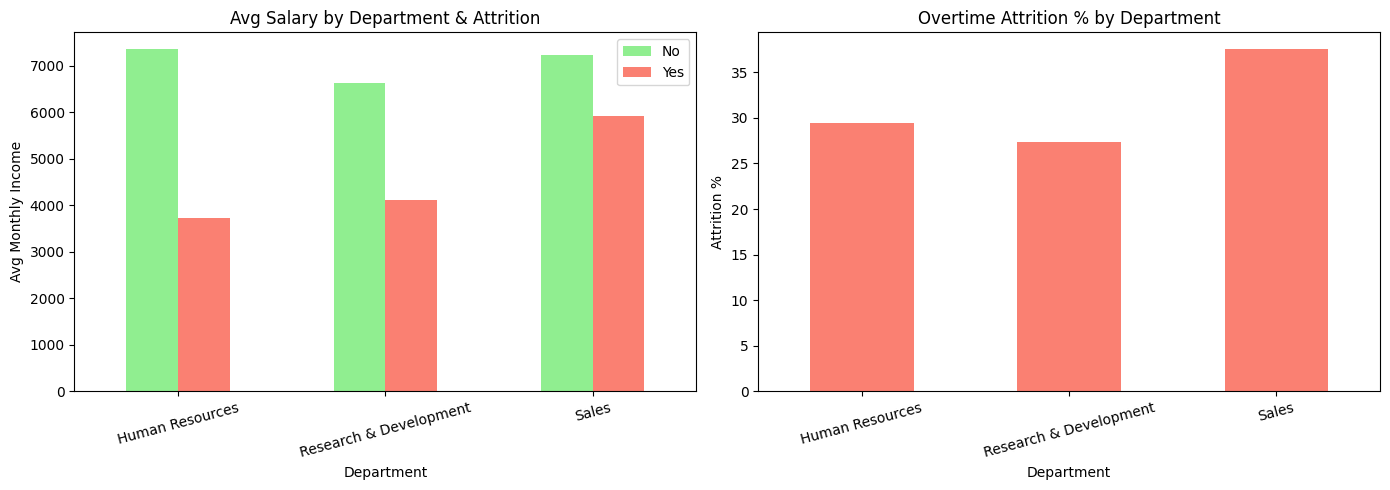

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Department vs Avg Salary (Attrition wise)
dept_salary = df.groupby(['Department', 'Attrition'])['MonthlyIncome'].mean().unstack()
dept_salary.plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'])
axes[0].set_title('Avg Salary by Department & Attrition')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Avg Monthly Income')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['No', 'Yes'])

# Chart 2 — Department vs Overtime Attrition
dept_overtime = df[df['OverTime'] == 'Yes'].groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
dept_overtime['Yes'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Overtime Attrition % by Department')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Attrition %')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('hr_attrition_clean.csv', index=False)